# 04 Evaluate VDJdb

Compute F1, purity, concentration, and fragmentation metrics for GLC and YLQ runs.

In [1]:
from pathlib import Path
import os
import sys

for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "benchmark" / "data_sources.py").exists():
        REPO_ROOT = candidate
        break
else:
    raise RuntimeError("Could not find repository root containing benchmark/data_sources.py")

os.chdir(REPO_ROOT)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
print(f"Benchmark repo root: {REPO_ROOT}")

Benchmark repo root: C:\Users\lizzka239\projects\tcrempnet


[2026-05-26 22:14:50] Starting VDJdb evaluation
[2026-05-26 22:14:50] Using repaired VDJdb metadata file: C:\Users\lizzka239\projects\tcrempnet\results\run_metadata\clustering_runs_vdjdb_repaired.tsv
[2026-05-26 22:14:50] Ensured benchmark output directories under C:\Users\lizzka239\projects\tcrempnet
[2026-05-26 22:14:50] Loading run metadata without consolidation: C:\Users\lizzka239\projects\tcrempnet\results\run_metadata\clustering_runs_vdjdb_repaired.tsv
[2026-05-26 22:14:50] Loaded run metadata rows=318, status_counts={'success': 225, 'error': 93}
[2026-05-26 22:14:50] Selecting assignment parquet files in C:\Users\lizzka239\projects\tcrempnet\results\clustering_assignments: dataset_mode=vdjdb, only_success=True, selected_runs=225, existing_files=6, missing_files=219, columns=17
[2026-05-26 22:14:51] Loaded assignment tables: files=6, rows=606345, columns=17
[2026-05-26 22:14:51] VDJdb assignments rows=606345, runs=6
[2026-05-26 22:14:53] Wrote VDJdb metrics rows=6: C:\Users\lizzk

<IPython.core.display.Markdown object>

<IPython.core.display.Markdown object>

    method        f1  precision    recall  weighted_cluster_purity
0   leiden  0.784612   0.731008  0.846804                 0.781133
1  vdbscan  0.746609   0.733520  0.760176                 0.777655
2   dbscan  0.647203   0.792832  0.568363                 0.798681

<IPython.core.display.Markdown object>

                        run_id    epitope  ... noise_fraction runtime_seconds
1   vdjdb_glc_leiden_grid_0002  GLCTLVAML  ...            0.0      111.339419
2  vdjdb_glc_vdbscan_grid_0001  GLCTLVAML  ...            0.0      137.666922
0   vdjdb_glc_dbscan_grid_0000  GLCTLVAML  ...            0.0      150.175076
3   vdjdb_ylq_dbscan_grid_0000  YLQPRTFLL  ...            0.0      149.961610
4   vdjdb_ylq_leiden_grid_0002  YLQPRTFLL  ...            0.0      105.222047
5  vdjdb_ylq_vdbscan_grid_0001  YLQPRTFLL  ...            0.0      106.614276

[6 rows x 15 columns]

<IPython.core.display.Markdown object>

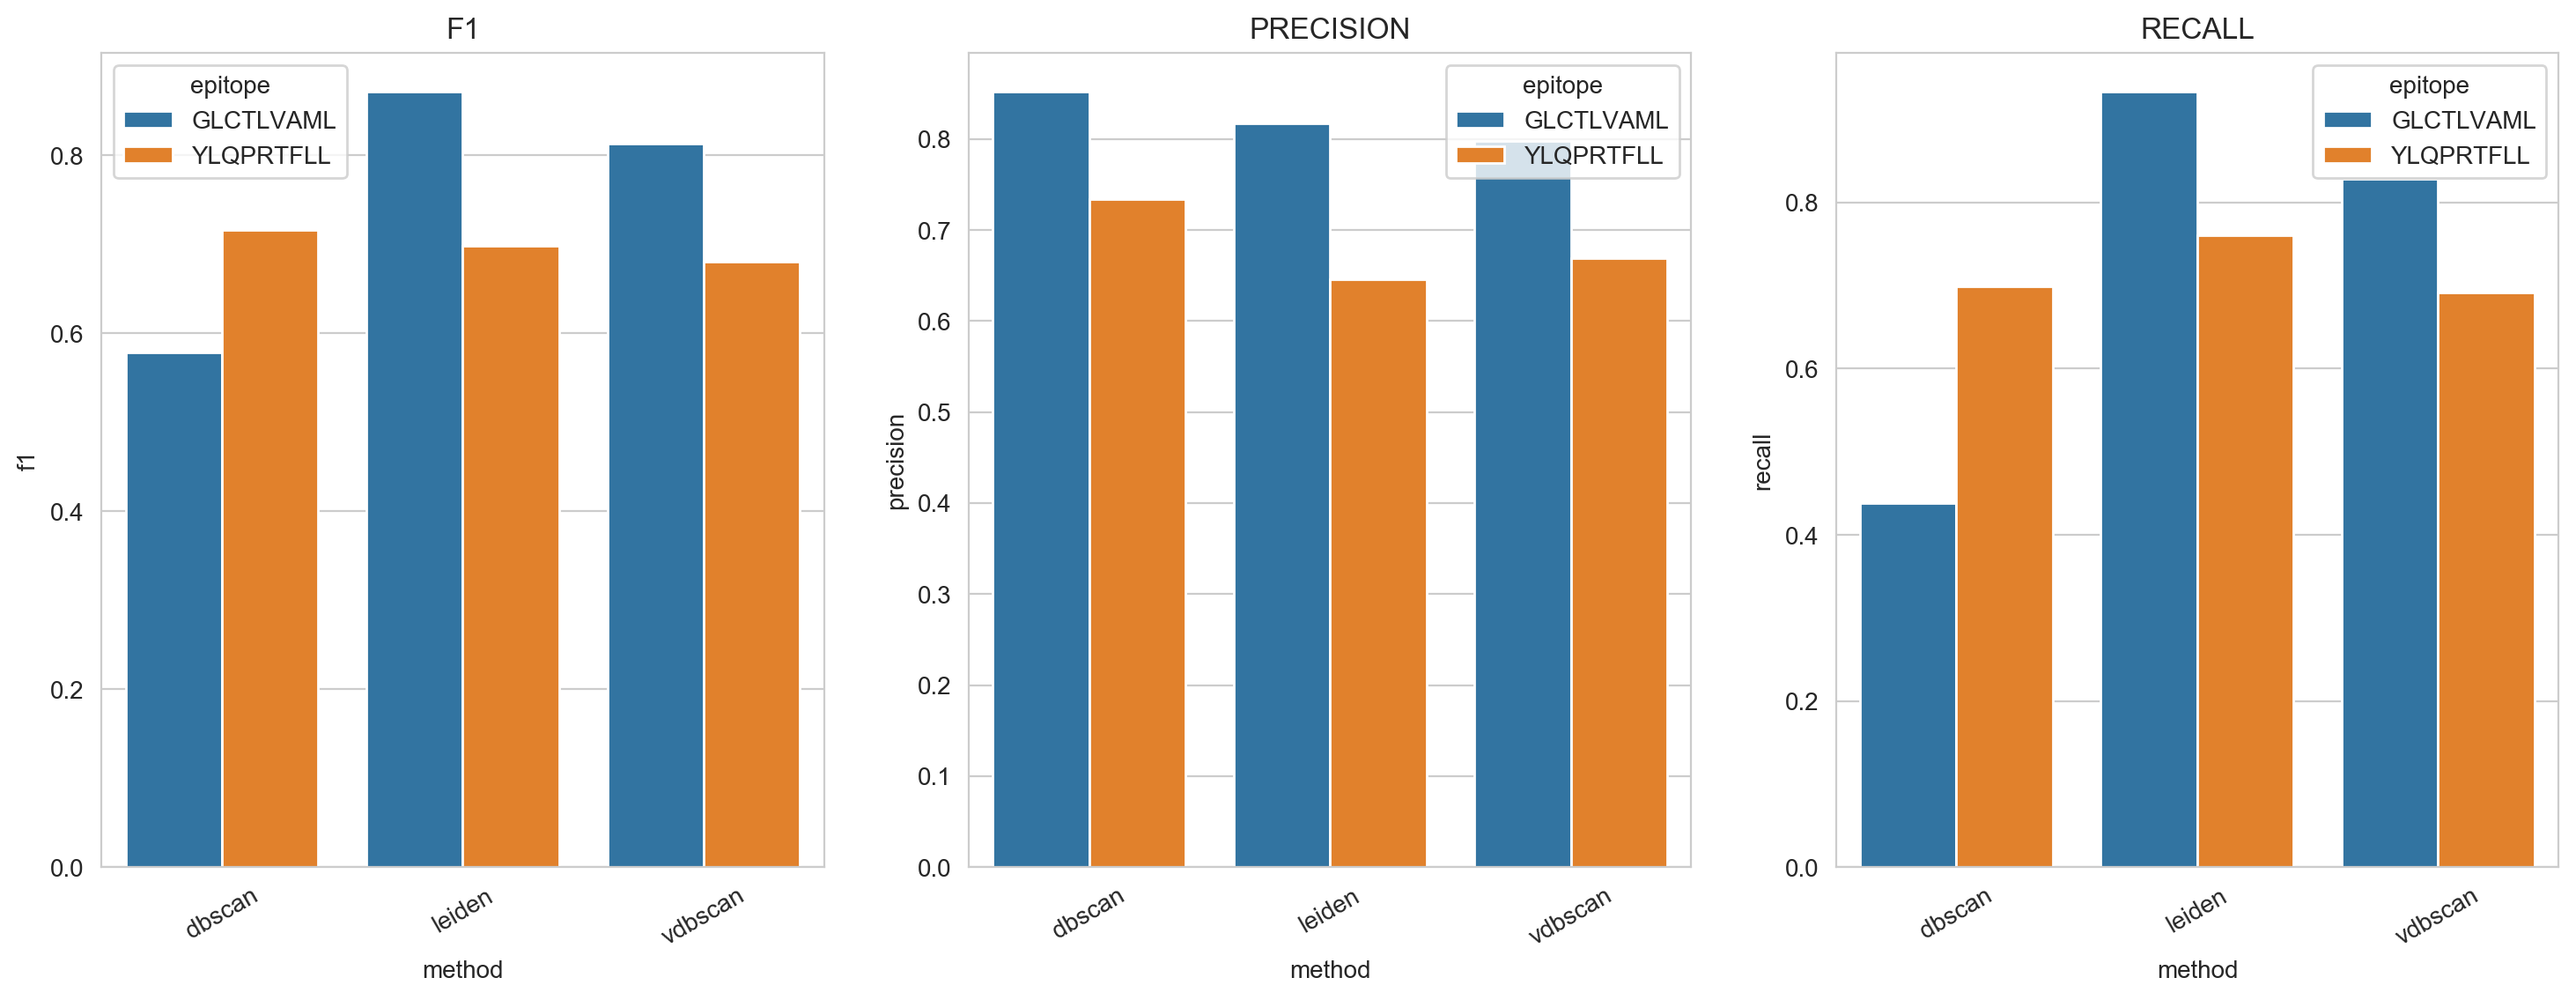

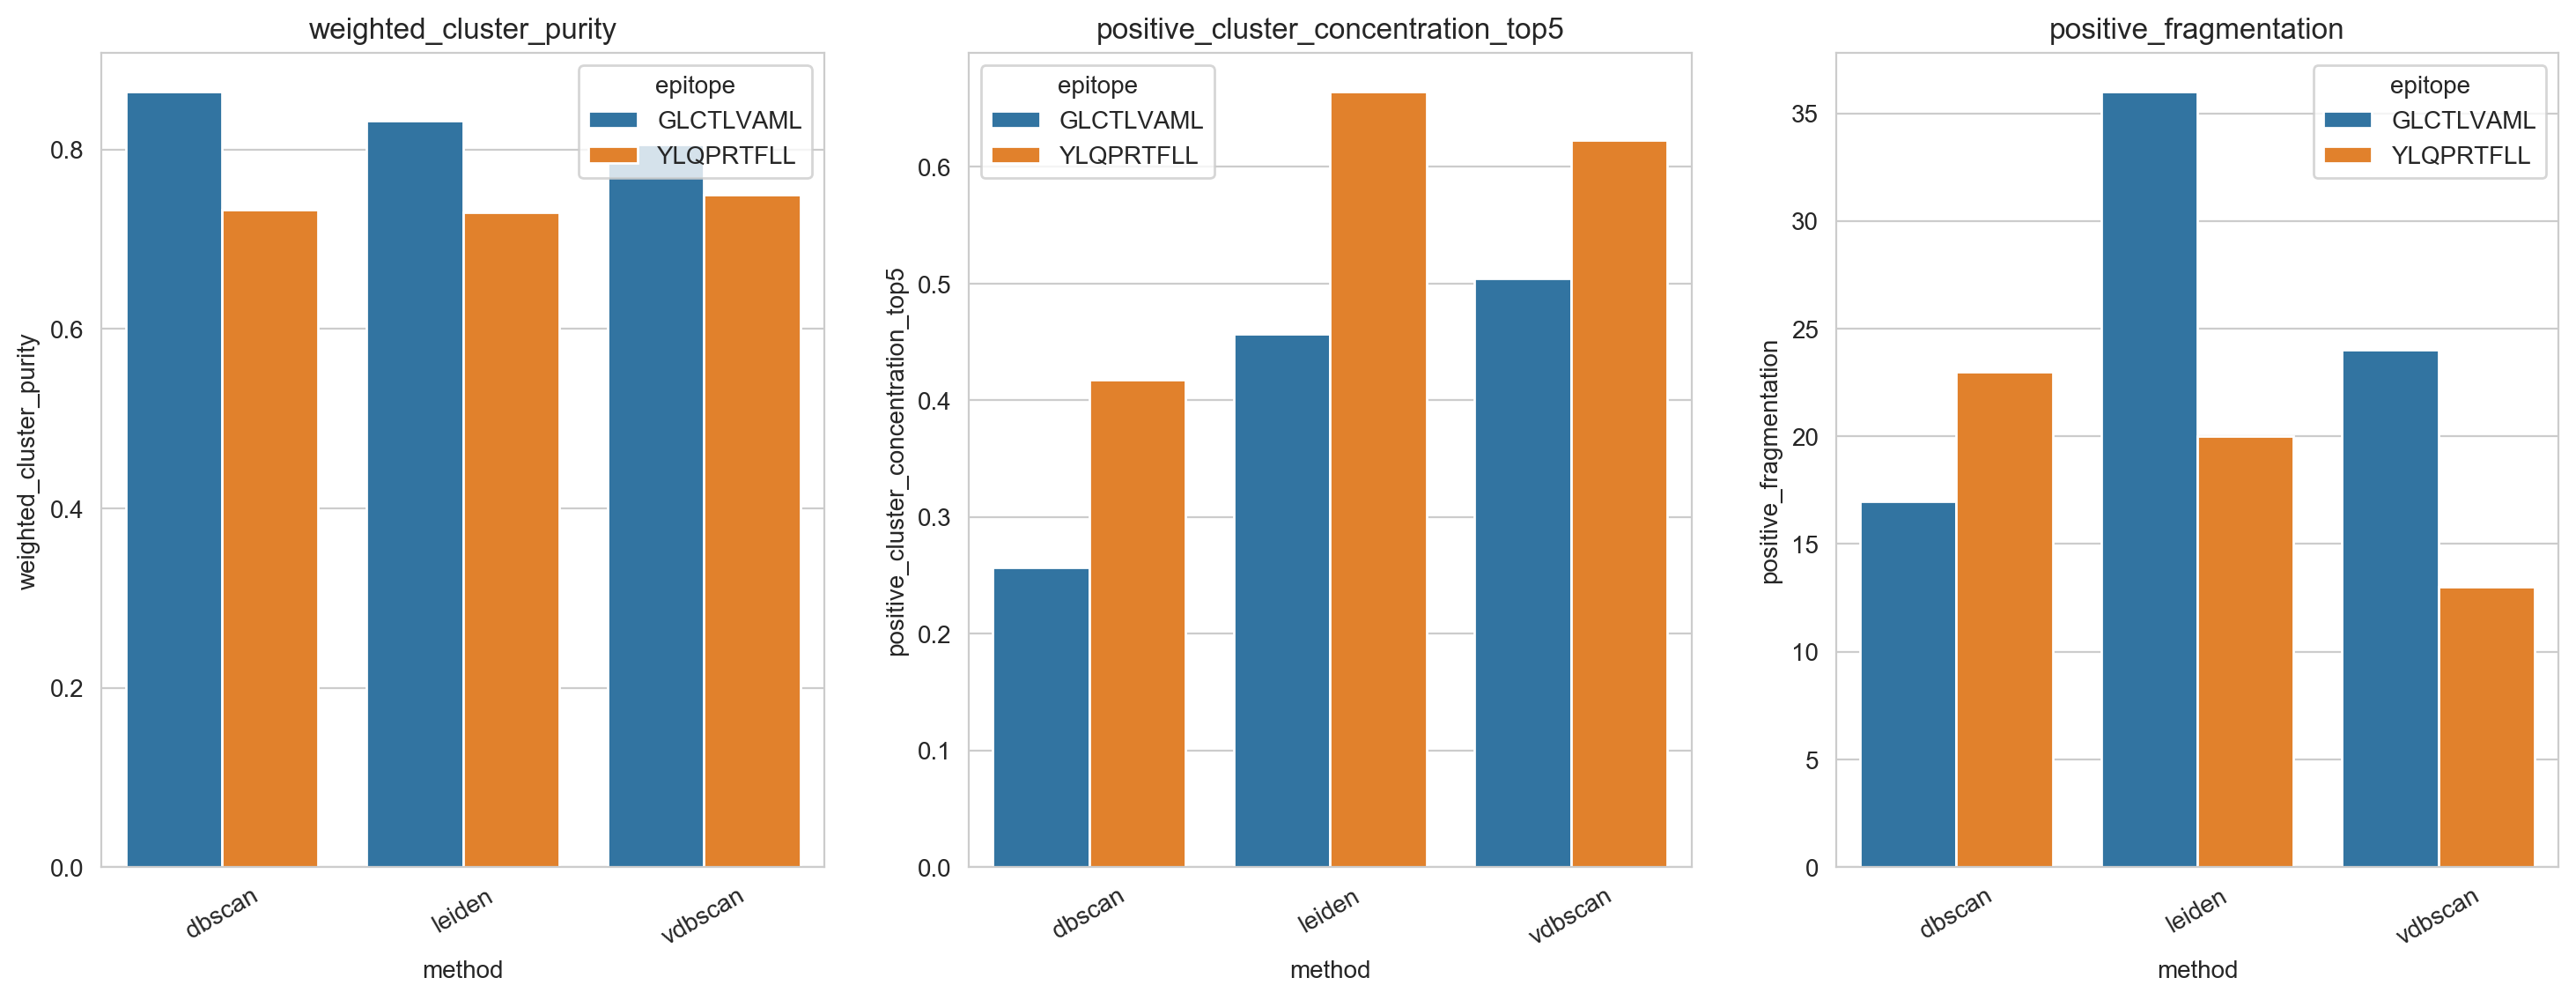

                        run_id    epitope  ... noise_fraction runtime_seconds
0   vdjdb_glc_dbscan_grid_0000  GLCTLVAML  ...            0.0      150.175076
1   vdjdb_glc_leiden_grid_0002  GLCTLVAML  ...            0.0      111.339419
2  vdjdb_glc_vdbscan_grid_0001  GLCTLVAML  ...            0.0      137.666922
3   vdjdb_ylq_dbscan_grid_0000  YLQPRTFLL  ...            0.0      149.961610
4   vdjdb_ylq_leiden_grid_0002  YLQPRTFLL  ...            0.0      105.222047

[5 rows x 15 columns]

In [2]:
from benchmark import run_vdjdb_evaluation
from benchmark.notebook_displays import show_vdjdb_notebook_outputs

metrics_df = run_vdjdb_evaluation()
show_vdjdb_notebook_outputs(metrics_df, REPO_ROOT)
metrics_df.head()

## Grid Search Interpretation

The aggregated benchmark plots above show who wins on average, but they hide two things that matter for model selection:

- where each method has a broad stable plateau versus a narrow fragile optimum;
- whether an interesting hybrid such as `vdbscan_leiden` has real high-performing pockets that are worth following up.

The cells below load the full VDJdb grid table and visualize the hyperparameter surface directly.

Out[1]: 
                                    run_id  ... vdbscan_sym_rule
0  vdjdb_glc_hierarchical_leiden_grid_0099  ...              NaN
1  vdjdb_glc_hierarchical_leiden_grid_0111  ...              NaN
2  vdjdb_glc_hierarchical_leiden_grid_0106  ...              NaN
3  vdjdb_glc_hierarchical_leiden_grid_0098  ...              NaN
4  vdjdb_glc_hierarchical_leiden_grid_0110  ...              NaN

[5 rows x 24 columns]


<IPython.core.display.Markdown object>

<IPython.core.display.Markdown object>

<IPython.core.display.Markdown object>

                 method    epitope   mean  ...    max  collapse_rate  range
0   hierarchical_leiden  GLCTLVAML  0.891  ...  0.904          0.000  0.024
1                leiden  GLCTLVAML  0.876  ...  0.896          0.000  0.066
2         leiden_dbscan  GLCTLVAML  0.697  ...  0.782          0.000  0.223
3                dbscan  GLCTLVAML  0.596  ...  0.631          0.000  0.082
4        vdbscan_leiden  GLCTLVAML  0.580  ...  0.901          0.147  0.901
5               vdbscan  GLCTLVAML  0.538  ...  0.848          0.167  0.848
6   hierarchical_leiden  YLQPRTFLL  0.751  ...  0.783          0.000  0.055
7        vdbscan_leiden  YLQPRTFLL  0.604  ...  0.801          0.171  0.801
8                dbscan  YLQPRTFLL  0.719  ...  0.755          0.000  0.067
9         leiden_dbscan  YLQPRTFLL  0.691  ...  0.778          0.000  0.243
10               leiden  YLQPRTFLL  0.694  ...  0.715          0.000  0.040
11              vdbscan  YLQPRTFLL  0.568  ...  0.732          0.154  0.732

[12 rows x 

<IPython.core.display.Markdown object>

      epitope  ...                                     parameter_json
0   GLCTLVAML  ...  {"cluster_min_samples":3,"cluster_pc_component...
1   GLCTLVAML  ...  {"cluster_min_samples":3,"cluster_pc_component...
2   GLCTLVAML  ...  {"cluster_min_samples":3,"cluster_pc_component...
3   GLCTLVAML  ...  {"cluster_min_samples":5,"cluster_pc_component...
4   GLCTLVAML  ...  {"cluster_min_samples":5,"cluster_pc_component...
5   GLCTLVAML  ...  {"cluster_min_samples":3,"cluster_pc_component...
6   YLQPRTFLL  ...  {"cluster_min_samples":3,"cluster_pc_component...
7   YLQPRTFLL  ...  {"cluster_min_samples":3,"cluster_pc_component...
8   YLQPRTFLL  ...  {"cluster_min_samples":3,"cluster_pc_component...
9   YLQPRTFLL  ...  {"cluster_min_samples":3,"cluster_pc_component...
10  YLQPRTFLL  ...  {"cluster_min_samples":3,"cluster_pc_component...
11  YLQPRTFLL  ...  {"cluster_min_samples":3,"cluster_pc_component...

[12 rows x 10 columns]

<IPython.core.display.Markdown object>

     epitope  ...                                     parameter_json
0  GLCTLVAML  ...  {"cluster_min_samples":5,"cluster_pc_component...
1  GLCTLVAML  ...  {"cluster_min_samples":3,"cluster_pc_component...
2  GLCTLVAML  ...  {"cluster_min_samples":3,"cluster_pc_component...
3  YLQPRTFLL  ...  {"cluster_min_samples":3,"cluster_pc_component...
4  YLQPRTFLL  ...  {"cluster_min_samples":3,"cluster_pc_component...
5  YLQPRTFLL  ...  {"cluster_min_samples":3,"cluster_pc_component...

[6 rows x 15 columns]

<IPython.core.display.Markdown object>

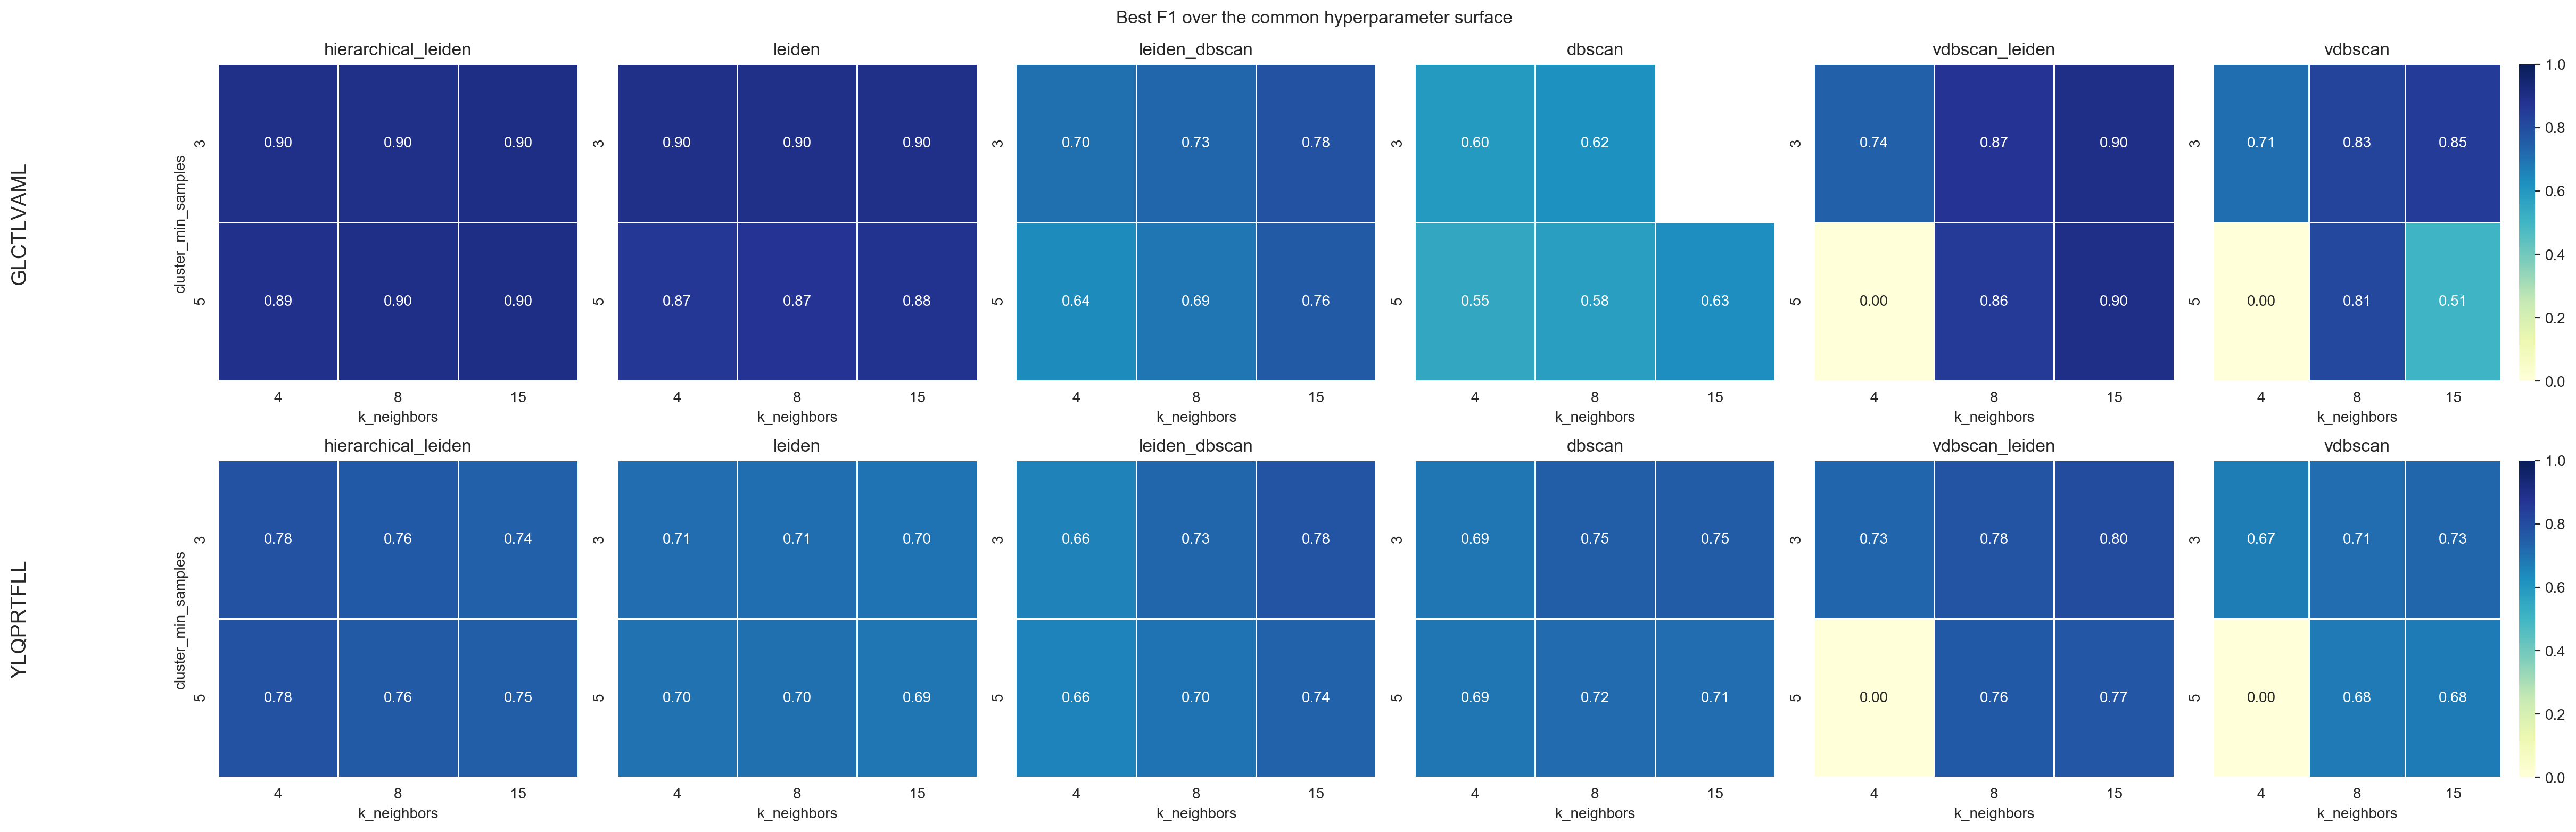

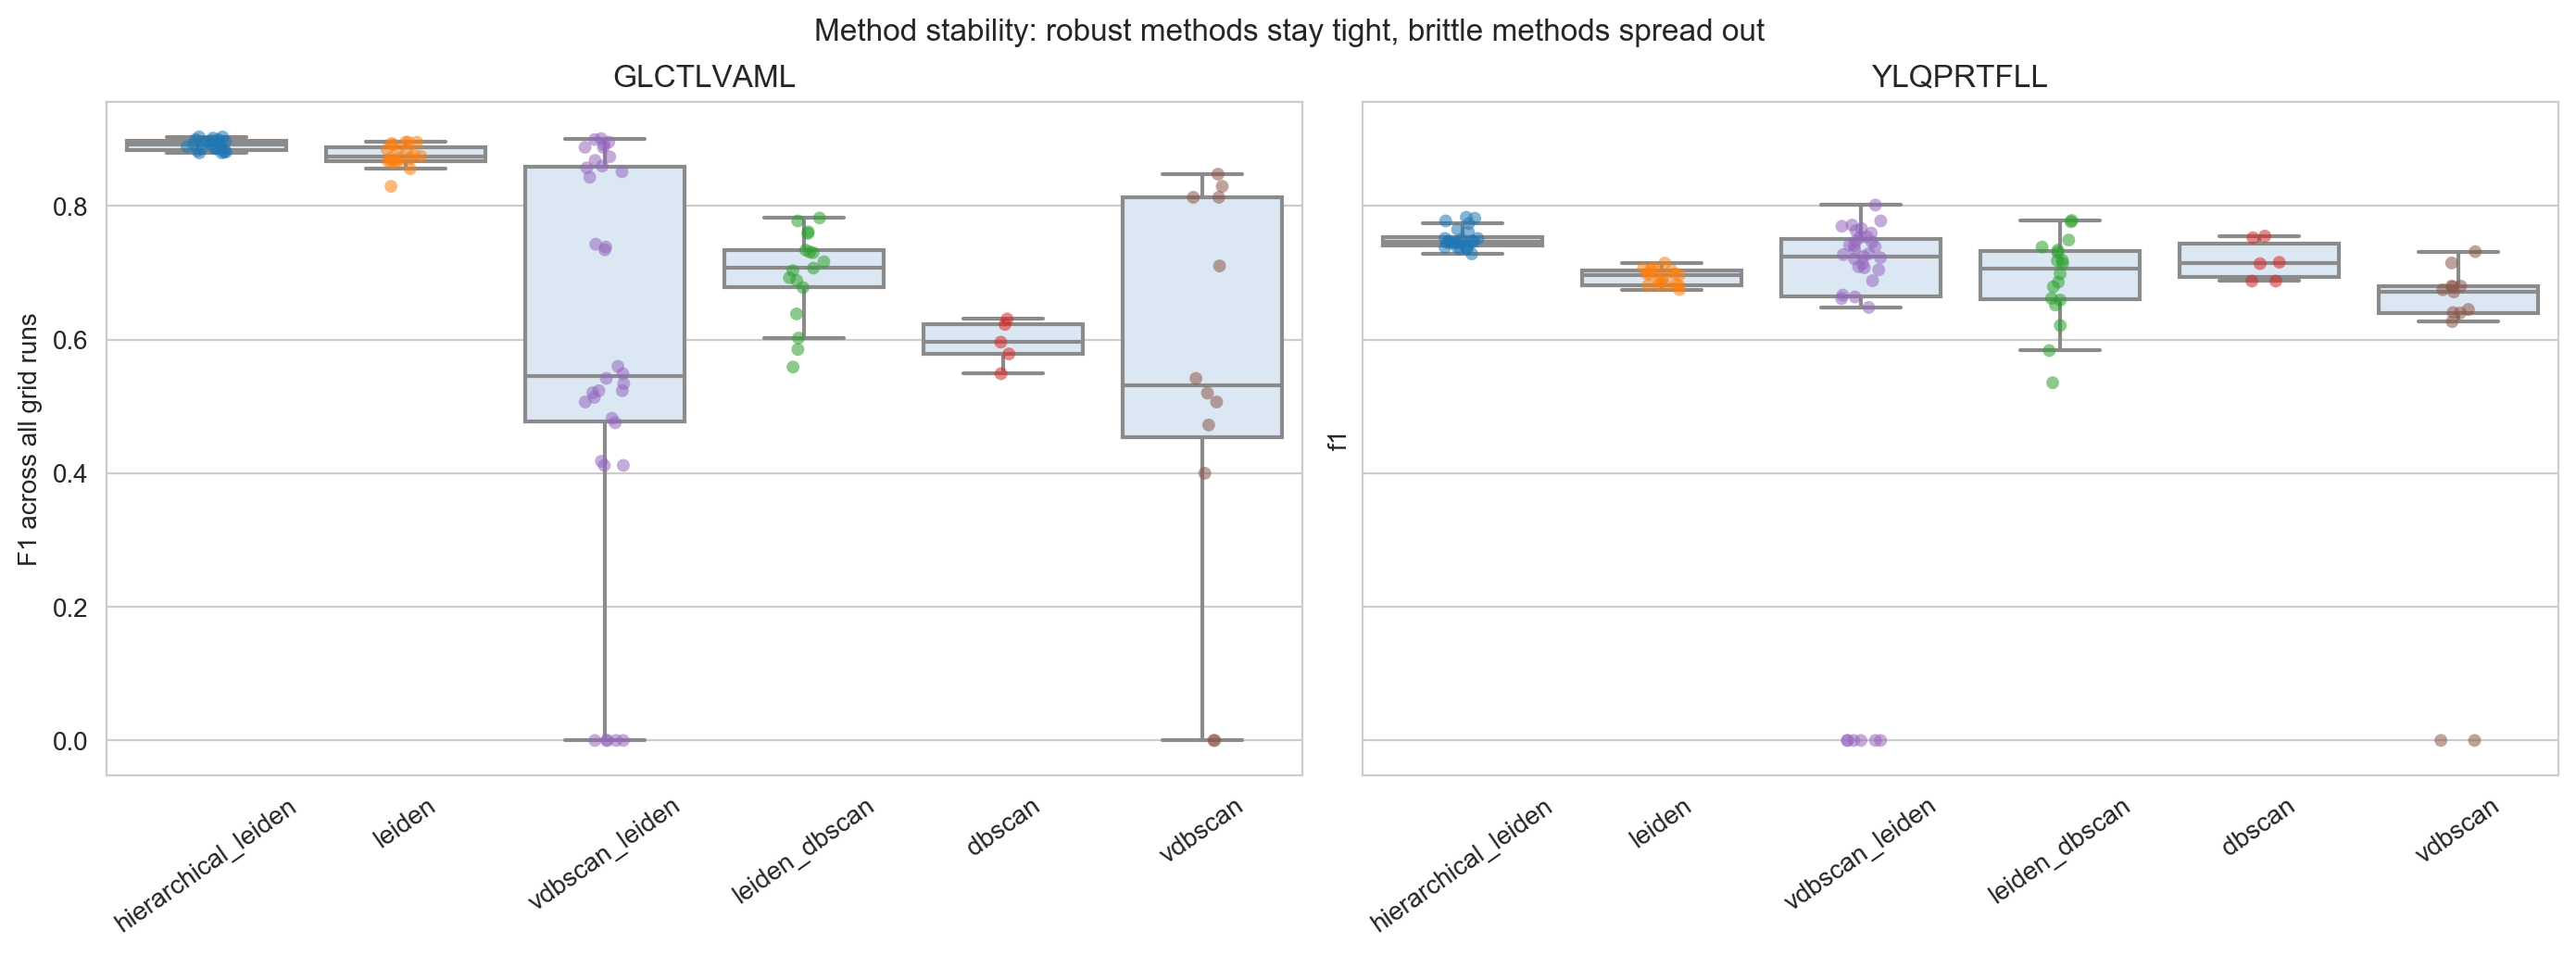

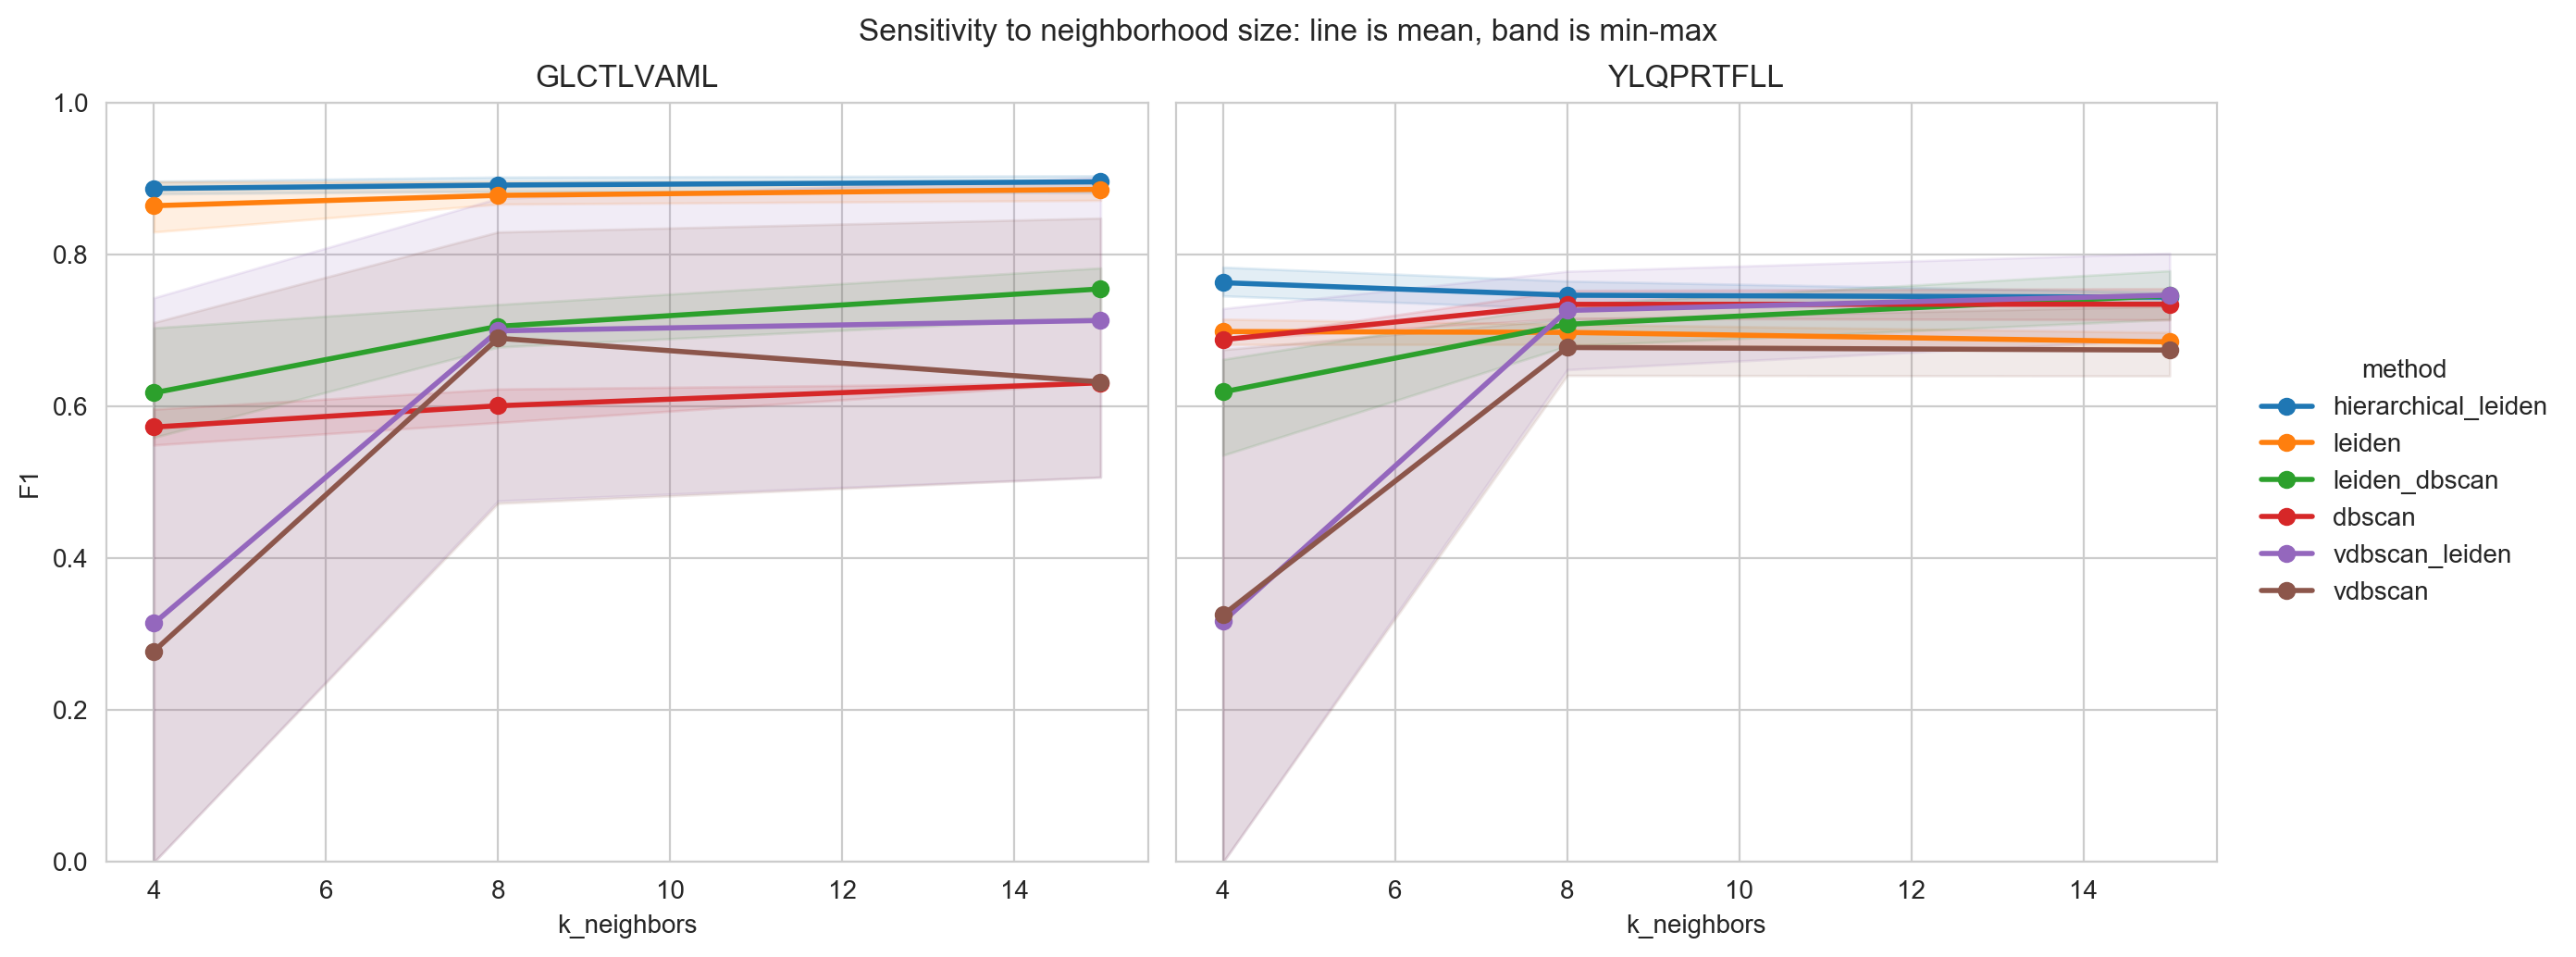

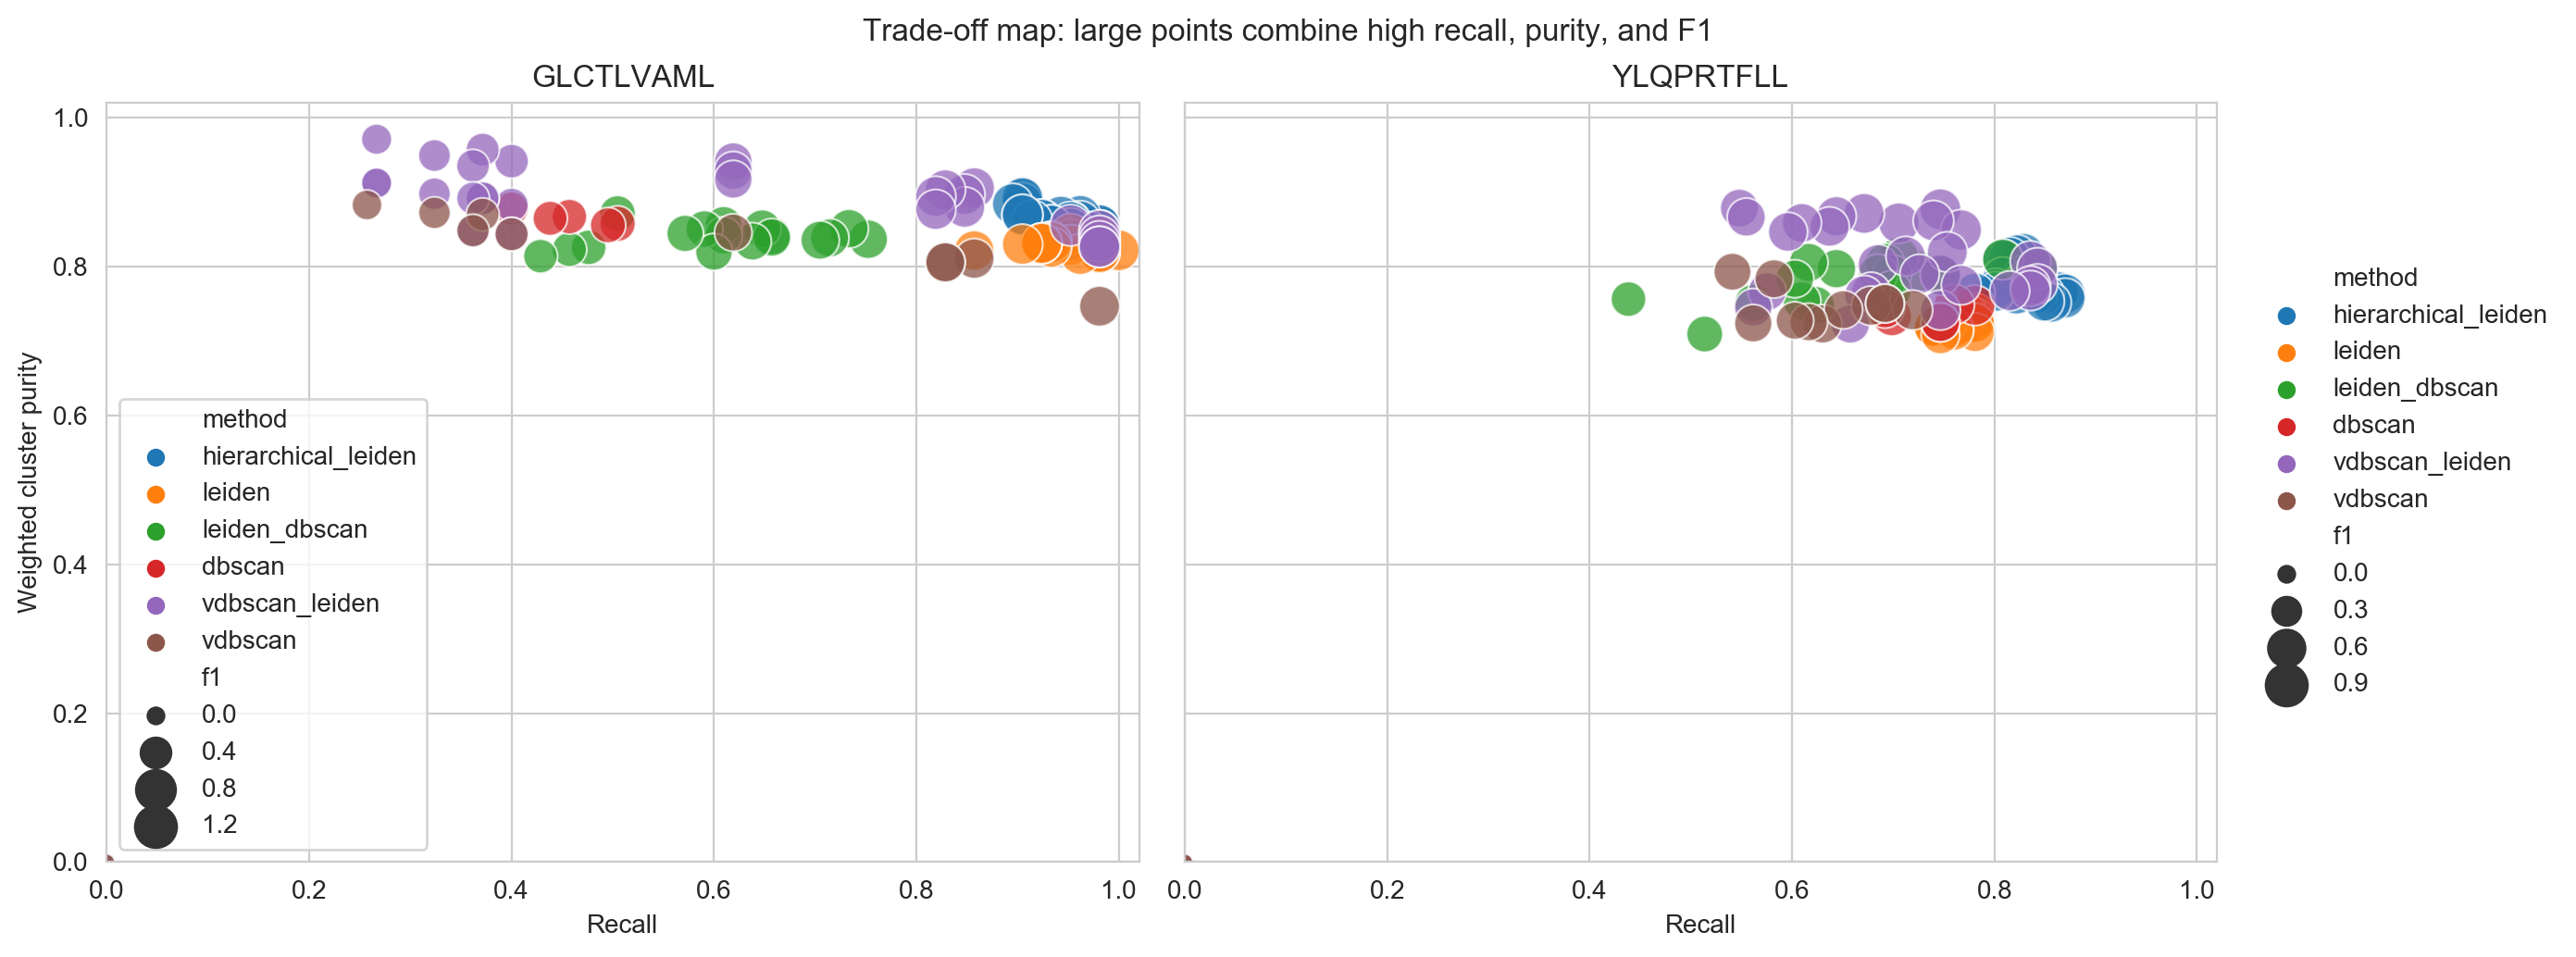

                                    run_id  ... vdbscan_sym_rule
0  vdjdb_glc_hierarchical_leiden_grid_0099  ...              NaN
1  vdjdb_glc_hierarchical_leiden_grid_0111  ...              NaN
2  vdjdb_glc_hierarchical_leiden_grid_0106  ...              NaN
3  vdjdb_glc_hierarchical_leiden_grid_0098  ...              NaN
4  vdjdb_glc_hierarchical_leiden_grid_0110  ...              NaN

[5 rows x 24 columns]

In [3]:
from pathlib import Path

from benchmark.vdjdb_grid_visualization import show_vdjdb_grid_search_outputs

grid_metrics_path = Path.home() / "Downloads" / "vdjdb_grid_metrics.csv"
grid_df = show_vdjdb_grid_search_outputs(grid_metrics_path, REPO_ROOT)
grid_df.head()